###### 2/25/2026
## Visualizations


#### Variable and Parameters Names
 - Climate = the original data set (146 observations with 19 parameters)
 - North = the original Northern Hemisphere
 - South = the original Southern Hemisphere
 - months = Monthly climate data
 - J.D = Jan - Dec (Yearly temp)
 - N.D = Dec - Nov (Meteorological Year)
 - DJF = Dec, Jan, Feb
 - MAM = Mar, Apr, May
 - JJA = June, July, Aug
 - SON = Sep, Oct, Nov

#### Color schemes???
- forecast = "coral"
- confidence = "skyblue"
- Original = "#348ABD" (blue), "firebrick", "teal"

In [7]:
# Libraries to for use
# pmdarima = "py" + "arima" and seems to be a strong choice for Python?
## documentation: https://alkaline-ml.com/pmdarima/modules/classes.html
import pandas as pd
from pmdarima.arima import ADFTest, ARIMA, AutoARIMA
from pmdarima.utils import as_series, acf, diff, pacf, plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import statsmodels.api as sm

# Setting graph style:
plt.style.use('bmh')

In [2]:
## Reading in data
Climate = pd.read_csv("Data/Global means.csv")
North = pd.read_csv("Data/Northern hemisphere means.csv", skiprows=1)
South = pd.read_csv("Data/Southern hemisphere means.csv", skiprows=1)

## Cleaning data
labelsDJ = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
labelsDJF = ['Jan', 'Feb']

Climate.at[0,"D-N"] = Climate.loc[0,labelsDJ].mean().round(2)
Climate.at[0,"DJF"] =  Climate.loc[0,labelsDJF].mean()

North.at[0,"D-N"] = North.loc[0,labelsDJ].mean().round(2)
North.at[0,"DJF"] =  North.loc[0,labelsDJF].mean()

South.at[0,"D-N"] = South.loc[0,labelsDJ].mean().round(2)
South.at[0,"DJF"] =  South.loc[0,labelsDJF].mean()

#Climate.shape
#South.shape
North.shape

(146, 19)

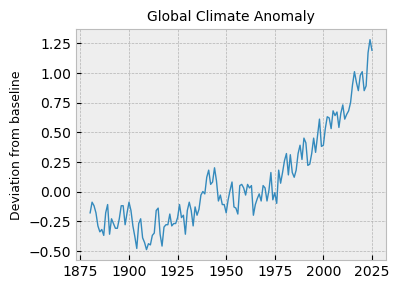

In [3]:
## Creating a general time series plots
plt.figure(figsize = (4,3))
plt.plot(Climate['Year'],Climate["J-D"], linewidth = 1, label = "Original", color = "#348ABD")
#plt.plot(Climate['Year'],Climate["J-D"], label = "Original")
plt.title("Global Climate Anomaly", fontsize=10)
plt.ylabel("Deviation from baseline", fontsize=9)
plt.show()

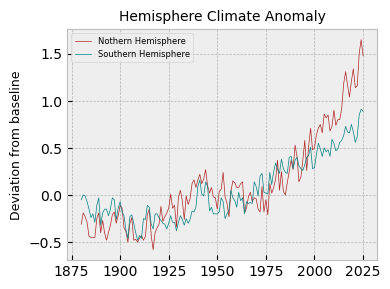

In [4]:
## Northern and Southern plots. 
plt.figure(figsize = (4,3))
#plt.plot(Climate['Year'],Climate["J-D"], linewidth = 1, label = "Original")
plt.plot(North['Year'],North["J-D"], linewidth = .5, label = "Nothern Hemisphere", color = "firebrick")
plt.plot(South['Year'],South["J-D"], linewidth = .5, label = "Southern Hemisphere", color = "teal")
plt.title("Hemisphere Climate Anomaly", fontsize=10)
plt.ylabel("Deviation from baseline", fontsize= 9)
plt.legend(fontsize=6)
plt.show()

In [10]:
### Simple regression on only J-D ~ Year  ## i have no idea what broke here..... 
y = Climate['J-D']
X = sm.add_constant(Climate['Year'])

model = sm.OLS(y, X).fit()
model.summary()

mse = np.mean((model.predict(X)  - Climate["J-D"])**2)
print(f'Mean Squared Error for complete data: {mse:.6f}')

years = Climate["Year"].astype(int)

year = as_series(Climate["J-D"])
year.index = pd.to_datetime(
    [f"{y}-01"
     for y in years]
)
forecast = model.predict(X)
forecast.index = pd.date_range(start = "1880-01-01", periods = len(forecast), freq='YS')
    
plt.figure(figsize = (5,3))
plt.plot(year, linewidth = .7, label = "Original")
plt.plot(forecast, linestyle = "--", linewidth = 1, color = "coral", label = "Forecast")
plt.title("Climate Anomaly vs Year", fontsize = 10)
plt.ylabel("Deviation from baseline average", fontsize = 8)
plt.legend(fontsize = 8)
plt.show()

ValueError: The indices for endog and exog are not aligned